In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon, browse_swot_2km
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, prepared_drifters, prepared_wd, prepared_alti

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0, U

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

In [39]:
comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
            dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='15')]
DS = dataset_coloc_combs(comb_list, nearest =False).drop_sel(row_number = err_acc)/U
DSS = DS.where(DS.depth==0, drop=True).isel(id_comb=0)
DSD = DS.where(DS.depth==15, drop=True).isel(id_comb=1)

nofilter__swot2kmnaive_etaf__rio_0era5
nofilter__swot2kmnaive_etaf__rio_15era5


______
# Distribution

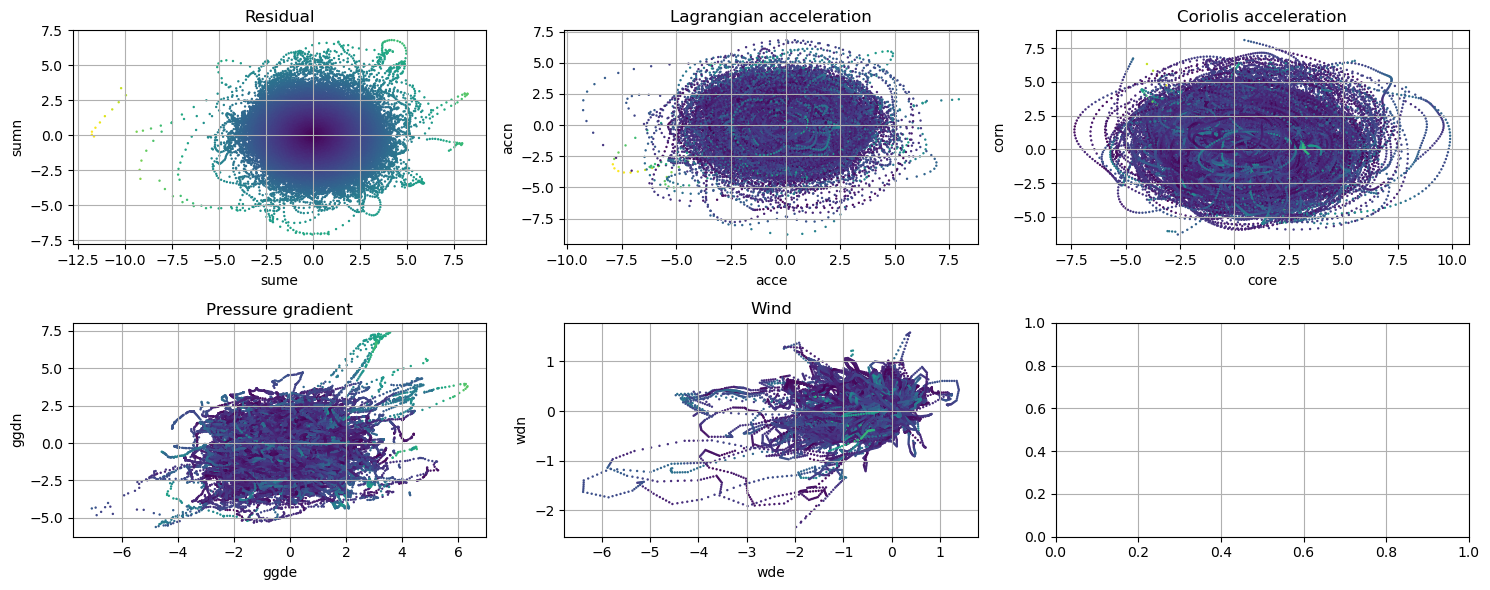

In [40]:
fig, axs = plt.subplots(2, 3, figsize=(15, 6))
axs = axs.flatten()
r=30
s=3
c = np.sqrt(DSS.sume**2+DSS.sumn**2)*r

ax=axs[0]
DSS.plot.scatter(x='sume', y='sumn',s=s, c=c,lw=0,  ax=ax)
ax.set_title('Residual')

ax=axs[1]
DSS.plot.scatter(x='acce', y='accn',s=s, c=c, lw=0,ax=ax)
ax.set_title('Lagrangian acceleration')

ax=axs[2]
DSS.plot.scatter(x='core',y= 'corn',s=s, c=c,lw=0, ax=ax)
ax.set_title('Coriolis acceleration')

ax=axs[3]
DSS.plot.scatter(x='ggde', y='ggdn',s=s, c=c,lw=0, ax=ax)
ax.set_title('Pressure gradient')

ax=axs[4]
DSS.plot.scatter(x='wde', y='wdn',s=s, c=c, lw=0, ax=ax)
ax.set_title('Wind')


for ax in axs :
    ax.grid()

fig.tight_layout()


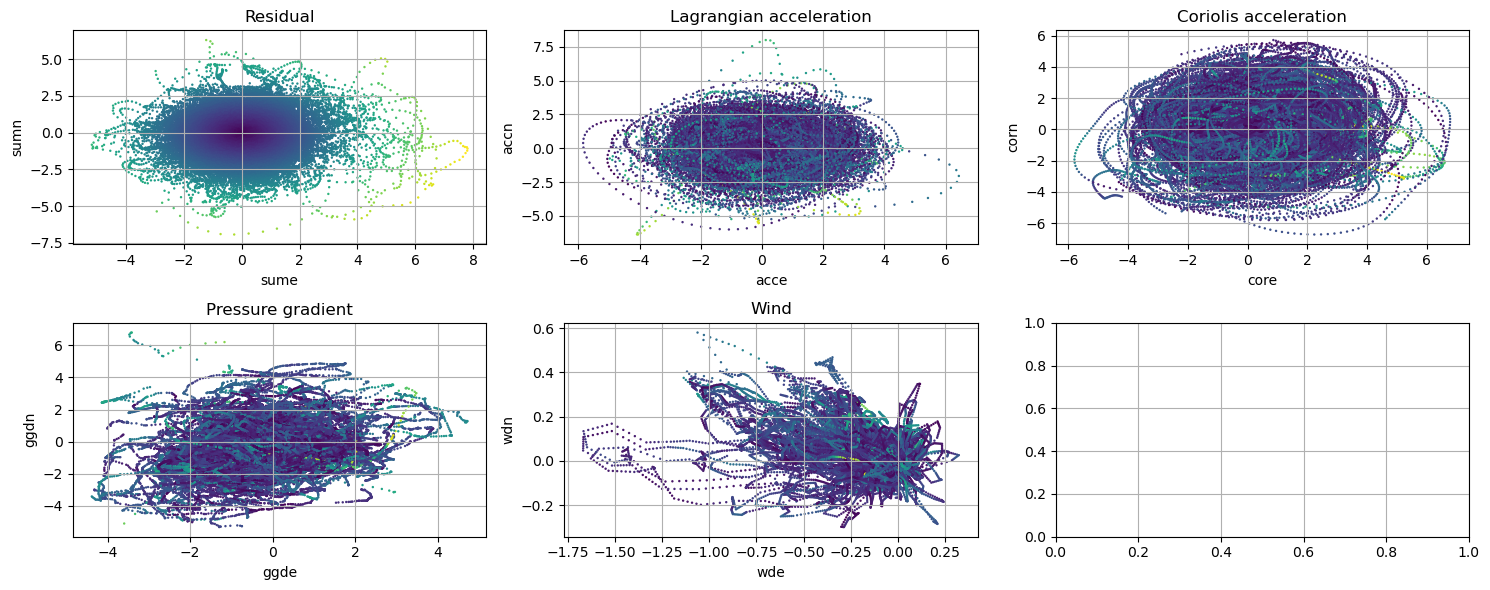

In [54]:
fig, axs = plt.subplots(2, 3, figsize=(15, 6))
axs = axs.flatten()
r=30
s=3
c = np.sqrt(DSD.sume**2+DSD.sumn**2)*r

ax=axs[0]
DSD.plot.scatter(x='sume', y='sumn',s=s, c=c,lw=0,  ax=ax)
ax.set_title('Residual')

ax=axs[1]
DSD.plot.scatter(x='acce', y='accn',s=s, c=c, lw=0,ax=ax)
ax.set_title('Lagrangian acceleration')

ax=axs[2]
DSD.plot.scatter(x='core',y= 'corn',s=s, c=c,lw=0, ax=ax)
ax.set_title('Coriolis acceleration')

ax=axs[3]
DSD.plot.scatter(x='ggde', y='ggdn',s=s, c=c,lw=0, ax=ax)
ax.set_title('Pressure gradient')

ax=axs[4]
DSD.plot.scatter(x='wde', y='wdn',s=s, c=c, lw=0, ax=ax)
ax.set_title('Wind')


for ax in axs :
    ax.grid()

fig.tight_layout()


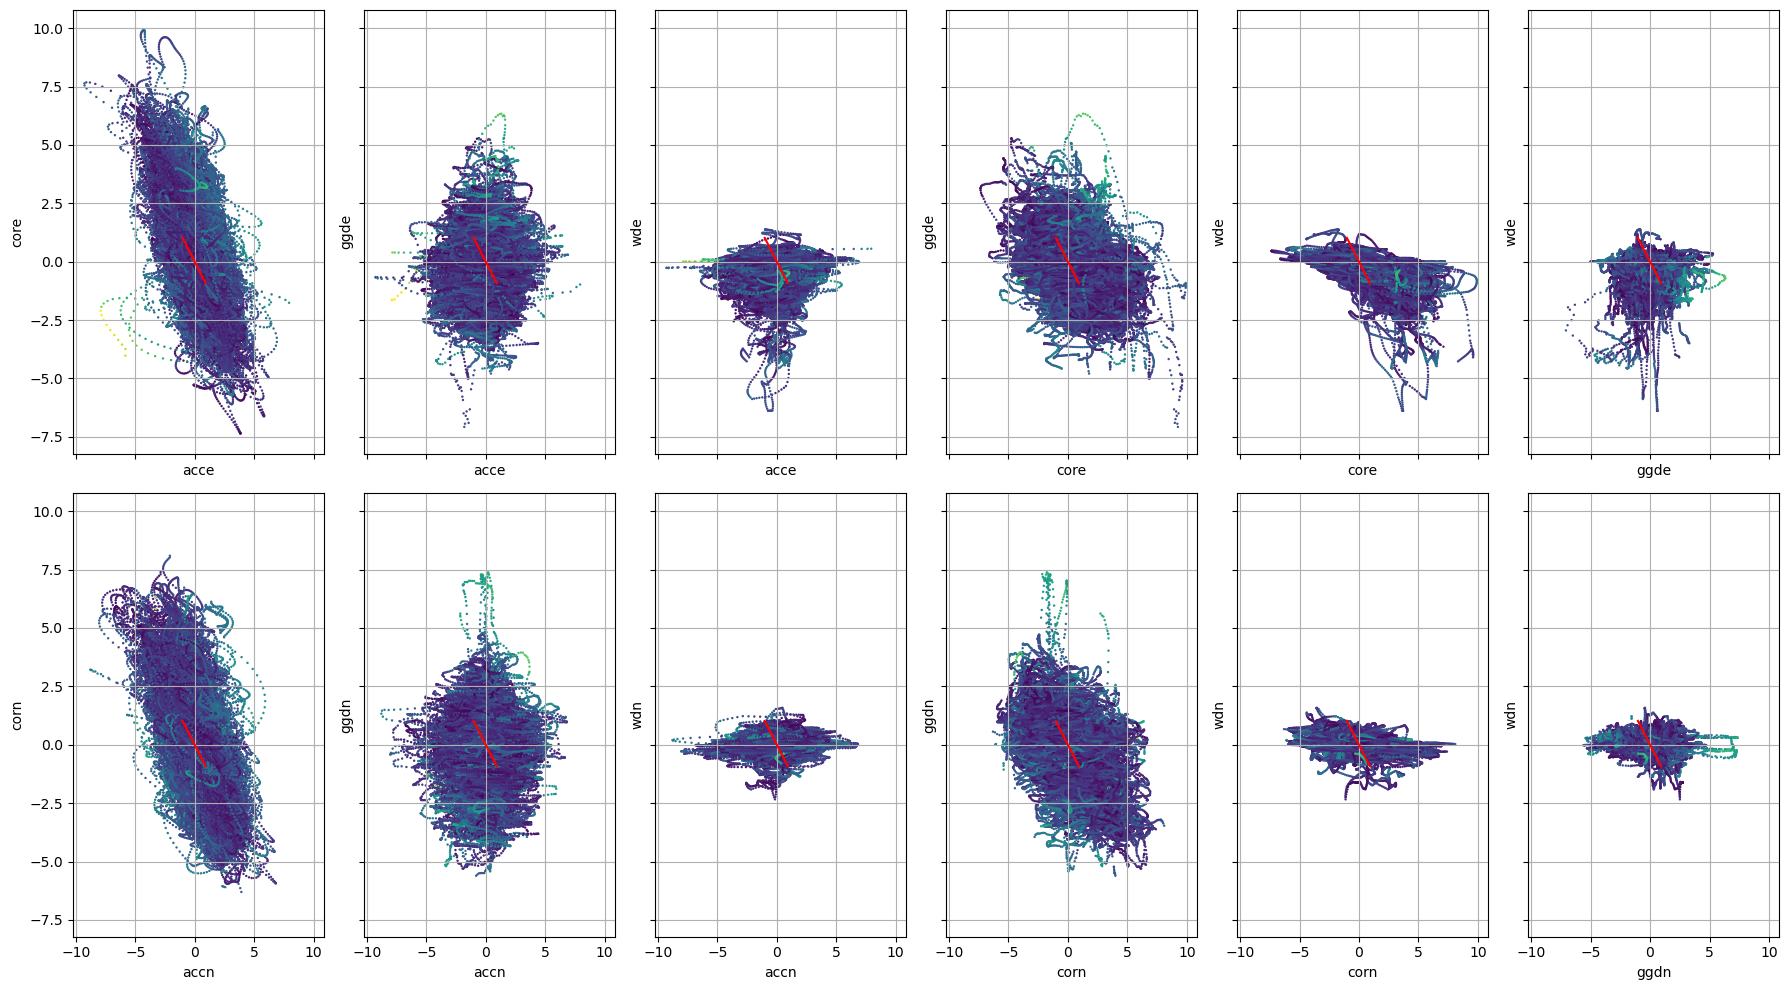

In [44]:
fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(18, 10), sharex=True, sharey=True)
axs =axs.flatten()

r=30
s=3
c = np.sqrt(DSS.sume**2+DSS.sumn**2)*r

DSS.plot.scatter(x='acce', y='core', s = s,c=c,lw=0, ax=axs[0])
DSS.plot.scatter(x='acce', y='ggde', s = s,c=c,lw=0, ax=axs[1])
DSS.plot.scatter(x='acce', y='wde', s = s,c=c,lw=0, ax=axs[2])
DSS.plot.scatter(x='core', y='ggde', s = s,c=c,lw=0, ax=axs[3])
DSS.plot.scatter(x='core', y='wde', s = s,c=c,lw=0, ax=axs[4])
DSS.plot.scatter(x='ggde', y='wde', s = s,c=c,lw=0, ax=axs[5])


DSS.plot.scatter(x='accn', y='corn', s = s,c=c,lw=0, ax=axs[6])
DSS.plot.scatter(x='accn', y='ggdn', s = s,c=c,lw=0, ax=axs[7])
DSS.plot.scatter(x='accn', y='wdn', s = s,c=c,lw=0, ax=axs[8])
DSS.plot.scatter(x='corn', y='ggdn', s = s,c=c,lw=0, ax=axs[9])
DSS.plot.scatter(x='corn', y='wdn', s = s,c=c,lw=0, ax=axs[10])
DSS.plot.scatter(x='ggdn', y='wdn', s = s,c=c,lw=0, ax=axs[11])


x = np.arange(-1e-5/U, 1e-5/U, 1e-6/U)
for ax in axs:
    ax.grid()
#    ax.plot(x, x, c='grey')
    ax.plot(x, -x, c='r')
    
    ax.set_title('')

fig.tight_layout()

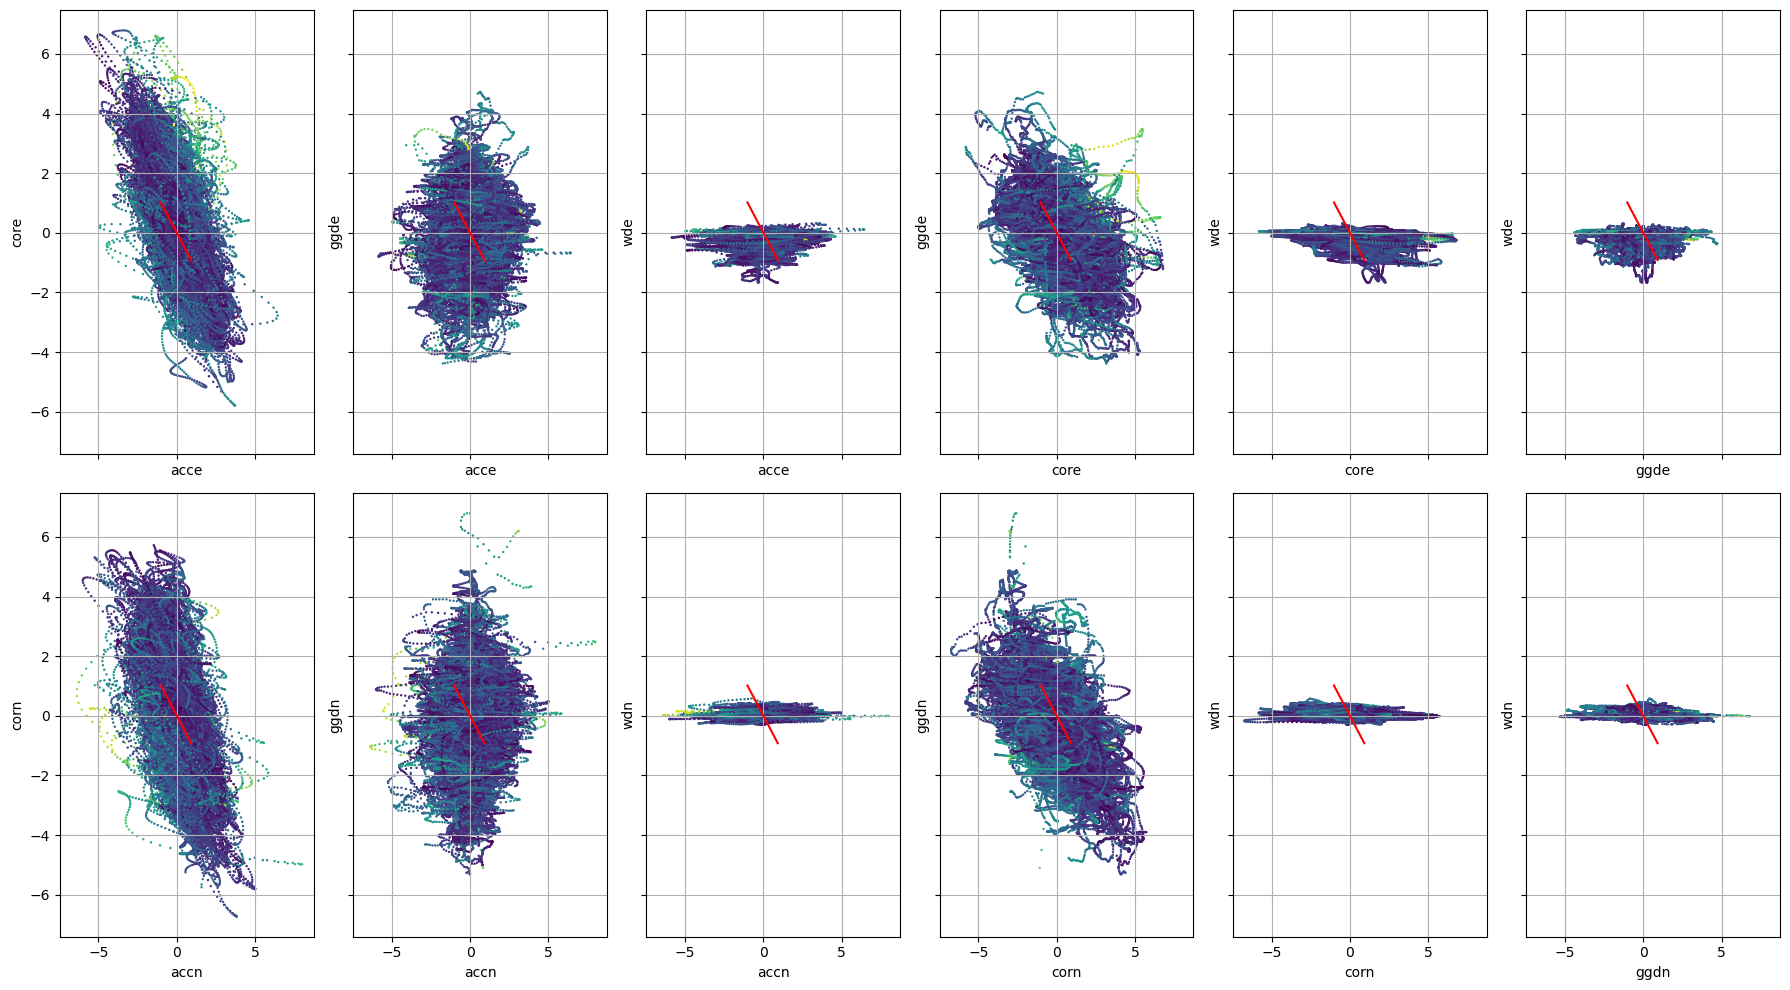

In [55]:
fig, axs = plt.subplots(nrows=2, ncols=6, figsize=(18, 10), sharex=True, sharey=True)
axs =axs.flatten()

r=30
s=3
c = np.sqrt(DSD.sume**2+DSD.sumn**2)*r

DSD.plot.scatter(x='acce', y='core', s = s,c=c,lw=0, ax=axs[0])
DSD.plot.scatter(x='acce', y='ggde', s = s,c=c,lw=0, ax=axs[1])
DSD.plot.scatter(x='acce', y='wde', s = s,c=c,lw=0, ax=axs[2])
DSD.plot.scatter(x='core', y='ggde', s = s,c=c,lw=0, ax=axs[3])
DSD.plot.scatter(x='core', y='wde', s = s,c=c,lw=0, ax=axs[4])
DSD.plot.scatter(x='ggde', y='wde', s = s,c=c,lw=0, ax=axs[5])


DSD.plot.scatter(x='accn', y='corn', s = s,c=c,lw=0, ax=axs[6])
DSD.plot.scatter(x='accn', y='ggdn', s = s,c=c,lw=0, ax=axs[7])
DSD.plot.scatter(x='accn', y='wdn', s = s,c=c,lw=0, ax=axs[8])
DSD.plot.scatter(x='corn', y='ggdn', s = s,c=c,lw=0, ax=axs[9])
DSD.plot.scatter(x='corn', y='wdn', s = s,c=c,lw=0, ax=axs[10])
DSD.plot.scatter(x='ggdn', y='wdn', s = s,c=c,lw=0, ax=axs[11])


x = np.arange(-1e-5/U, 1e-5/U, 1e-6/U)
for ax in axs:
    ax.grid()
#    ax.plot(x, x, c='grey')
    ax.plot(x, -x, c='r')
    
    ax.set_title('')

fig.tight_layout()

# PDF

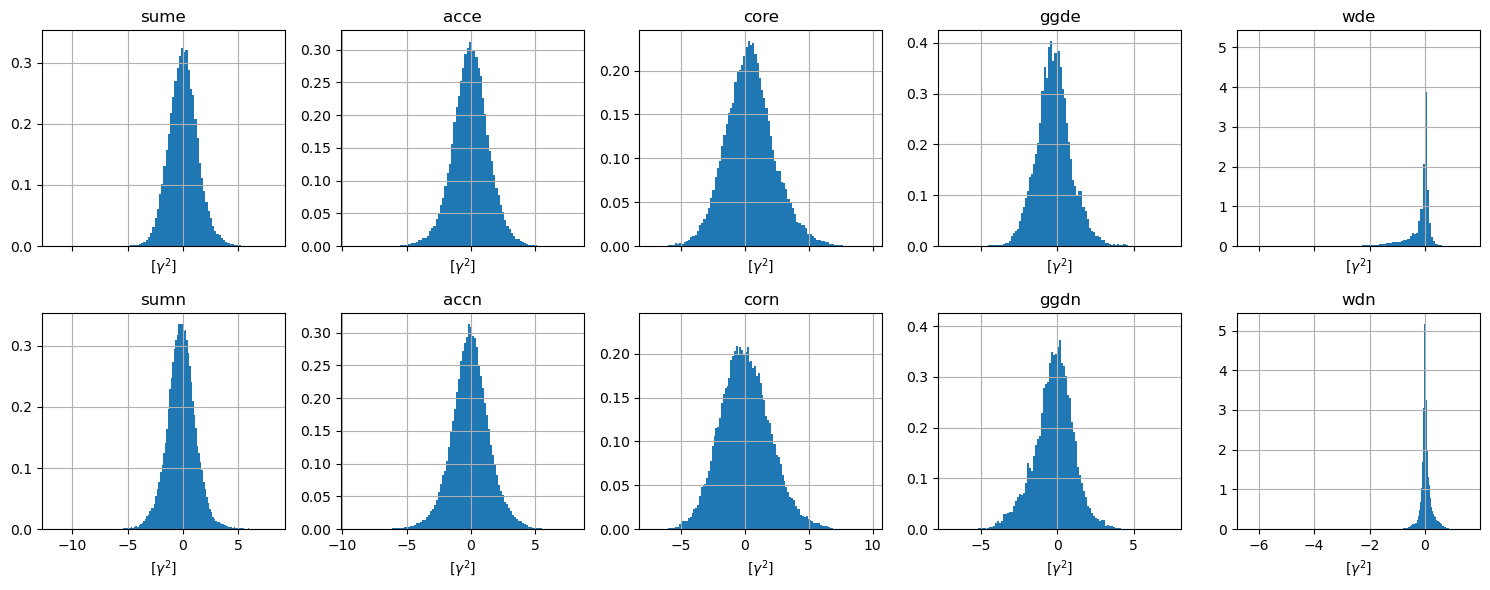

In [53]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6), sharey='col', sharex='col')
axs = axs.flatten()
r=30
s=3
#c = np.sqrt(DSS.sume**2+DSS.sumn**2)*r
i=0
for dir in ['e', 'n'] :
    for v in ['sum', 'acc', 'cor', 'ggd', 'wd']:
        ax = axs[i]
        DSS[v + dir].plot.hist(ax=ax, bins=100, density=True)
        ax.set_title(v+dir)
        ax.set_xlabel(r'[$\gamma^2$]')
        i+=1

for ax in axs :
    ax.grid()

fig.tight_layout()


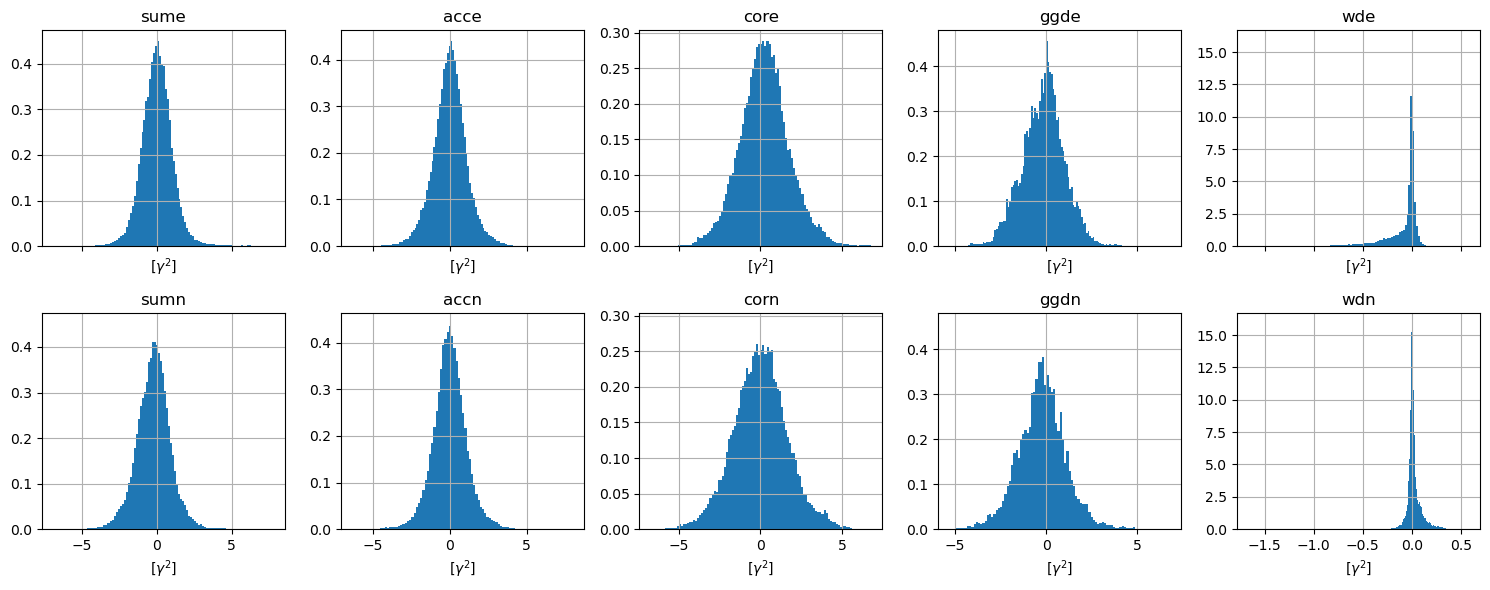

In [56]:
fig, axs = plt.subplots(2, 5, figsize=(15, 6), sharey='col', sharex='col')
axs = axs.flatten()
r=30
s=3
#c = np.sqrt(DSS.sume**2+DSS.sumn**2)*r
i=0
for dir in ['e', 'n'] :
    for v in ['sum', 'acc', 'cor', 'ggd', 'wd']:
        ax = axs[i]
        DSD[v + dir].plot.hist(ax=ax, bins=100, density=True)
        ax.set_title(v+dir)
        ax.set_xlabel(r'[$\gamma^2$]')
        i+=1

for ax in axs :
    ax.grid()

fig.tight_layout()
